# 15. GBM 랩 (M2·M3)

> 선행 노트북: [14_cross_year_fold_lab.ipynb](14_cross_year_fold_lab.ipynb)
> 선행 설계서: [04-final-solution-blueprint.md](../docs/design/04-final-solution-blueprint.md) 7.1절,
> [06-preprocessing-guardrails.md](../docs/design/06-preprocessing-guardrails.md) 5.1·5.4절

설계서 04 7.1절의 **M2(그룹별 GBM)**와 **M3(pooled GBM + group id)**를 실행한다.

**연구 질문**

> GBM은 현재 챔피언(RandomForest + `spatial_idw2_all_group`)보다 나은가?
> 그 우위는 아홉 fold·세 검증 연도를 건너 유지되는가?

**이 노트북이 지고 있는 부담이 하나 더 있다.** 노트북 14가 보인 실패 모드 —
2024만 검증하는 fold 세트는 "부호 전부 일치"라는 가짜 확신을 발급한다 — 는
**후보가 늘어날 때 커진다.** 설계서 06 5.1절이 "GBM·fold·calibration으로 후보가
수십 개"가 되면 위험이 커진다고 예고한 바로 그 지점이다.

그래서 이 노트북은 **후보를 먼저 못 박고 시작한다.** 하이퍼파라미터를 fold 성적을
보고 조정하지 않는다. 조정하는 순간 그 fold는 검증셋이 아니라 학습셋이 된다.

---

**실행 방법.** 이 노트북은 로컬과 Colab 양쪽에서 같은 파일로 돈다.

| 환경 | 준비 |
|------|------|
| 로컬 | 저장소 안에서 열면 된다. 부트스트랩은 버전만 보고하고 넘어간다 |
| Colab | Drive `baram-data/open/`에 원자료 4개를 두고 첫 셀부터 순서대로 실행한다 |

Colab에서는 첫 셀이 런타임 재시작을 요구할 수 있다. 안내대로 재시작하고 그 셀을
다시 실행하면 된다. 학습은 CPU 바운드이며 **Colab 무료 런타임은 2코어**라
22코어 로컬보다 몇 배 느리다 — 시간을 넉넉히 잡을 것.


In [1]:
# 0) 실행 환경 부트스트랩 — Colab에서만 동작하고 로컬에서는 아무것도 하지 않는다
import importlib
import importlib.metadata as importlibMetadata
import os
import shutil
import subprocess
import sys
from pathlib import Path

try:
  import google.colab  # noqa: F401
  IN_COLAB = True
except ImportError:
  IN_COLAB = False

# 수치에 영향을 주는 다섯 개만 고정한다. 4절의 F0 재현 게이트(1e-9)가 여기에 걸린다.
PINS = {
  "numpy": "1.26.4",
  "pandas": "3.0.3",
  "scikit-learn": "1.9.0",
  "lightgbm": "4.7.0",
  "catboost": "1.2.10",
}
MODULE_OF = {
  "numpy": "numpy",
  "pandas": "pandas",
  "scikit-learn": "sklearn",
  "lightgbm": "lightgbm",
  "catboost": "catboost",
}
REPO_URL = "https://github.com/Dacon-Organization/baram-2026-wind-power-forecasting.git"
PINNED_COMMIT = "71e9cdd4bc8c1d637f30539d8ee610ec06a560a0"
REPO_DIR = Path("/content/baram")
DRIVE_OPEN = Path("/content/drive/MyDrive/baram-data/open")
REQUIRED_FILES = ["train/train_labels.csv", "train/ldaps_train.csv", "train/gfs_train.csv", "info.xlsx"]


def distributionVersion(distributionName):
  """설치 여부 판단용. dist-info가 중복이면 부정확하므로 설치 결정에만 쓴다."""
  try:
    return importlibMetadata.version(distributionName)
  except Exception:
    return None


def loadedVersion(moduleName):
  """실제로 import되는 버전. 결과를 좌우하는 것은 이쪽이다."""
  try:
    return getattr(importlib.import_module(moduleName), "__version__", None)
  except ImportError:
    return None


def reportVersions():
  """import되는 버전으로 보고하고, 고정본과 어긋난 것을 돌려준다."""
  drifted = {}
  for distributionName, pin in PINS.items():
    actual = loadedVersion(MODULE_OF[distributionName])
    if actual != pin:
      drifted[distributionName] = actual
    print(f"  {'OK ' if actual == pin else 'BAD'}  {distributionName:14s} {actual}  (기대 {pin})")
  return drifted


if not IN_COLAB:
  print("로컬 환경 — 부트스트랩을 건너뛴다")
  reportVersions()
else:
  from google.colab import drive

  drive.mount("/content/drive")

  if not (REPO_DIR / ".git").is_dir():
    subprocess.run(["git", "clone", "--quiet", REPO_URL, str(REPO_DIR)], check=True)
  pinnedCheckout = subprocess.run(
    ["git", "-C", str(REPO_DIR), "checkout", "--quiet", PINNED_COMMIT],
    capture_output=True, text=True,
  )
  if pinnedCheckout.returncode == 0:
    codeState = f"{PINNED_COMMIT[:8]} (고정 커밋)"
  else:
    # squash merge 후 브랜치가 지워지면 고정 커밋에 닿지 못한다. 그 사실을 숨기지 않는다.
    currentHead = subprocess.run(
      ["git", "-C", str(REPO_DIR), "rev-parse", "--short", "HEAD"],
      capture_output=True, text=True,
    ).stdout.strip()
    codeState = f"{currentHead} (고정 커밋에 닿지 못함 — 기본 브랜치, 코드가 다를 수 있음)"

  # data/raw/open 은 실제 디렉터리다 (MANIFEST.md·README.md가 커밋 대상).
  # Path.unlink()는 IsADirectoryError를 내므로 rmtree로 지운 뒤 링크를 건다.
  openDir = REPO_DIR / "data" / "raw" / "open"
  if openDir.is_symlink():
    openDir.unlink()
  elif openDir.exists():
    shutil.rmtree(openDir)
  openDir.parent.mkdir(parents=True, exist_ok=True)
  openDir.symlink_to(DRIVE_OPEN, target_is_directory=True)

  # 설치 결정은 metadata로 한다 — 아직 import하지 않은 것을 재보려면 이 방법뿐이다.
  toInstall = [f"{n}=={p}" for n, p in PINS.items() if distributionVersion(n) != p]
  if toInstall:
    print(f"설치: {toInstall}")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *toInstall], check=True)
  if distributionVersion("seaborn") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "seaborn"], check=True)

  # 한글 폰트 — 아래 fontCandidates 중 Colab에서 잡히는 것은 NanumGothic 뿐이다.
  if not list(Path("/usr/share/fonts/truetype").glob("nanum*")):
    subprocess.run(["apt-get", "-qq", "install", "-y", "fonts-nanum"], check=True)
  fontCache = Path.home() / ".cache" / "matplotlib"
  if fontCache.exists():
    shutil.rmtree(fontCache)
  if "matplotlib" in sys.modules:
    import matplotlib.font_manager as alreadyLoadedFontManager

    for nanumFont in Path("/usr/share/fonts/truetype").glob("nanum*/*.ttf"):
      alreadyLoadedFontManager.fontManager.addfont(str(nanumFont))

  os.chdir(REPO_DIR / "notebooks")

  print(f"코드      : {codeState}")
  print(f"작업 경로 : {Path.cwd()}")
  for relativePath in REQUIRED_FILES:
    path = openDir / relativePath
    size = path.stat().st_size if path.is_file() else 0
    print(f"  {'OK     ' if path.is_file() else 'MISSING'}  {relativePath:24s} {size:>13,} bytes")
  drifted = reportVersions()

  # pip로 깔아도 이미 import된 모듈은 바뀌지 않는다. Colab 런타임은 numpy를 미리 올려두므로
  # 첫 실행에서는 거의 항상 여기에 걸린다. 재시작 없이 진행하면 ABI 오류가 난다.
  if drifted:
    print()
    print("=" * 68)
    for distributionName, actual in drifted.items():
      print(f"  {distributionName}: 로드됨 {actual} ≠ 고정본 {PINS[distributionName]}")
    print("  런타임 > 세션 다시 시작 을 누른 뒤 이 셀을 다시 실행하세요.")
    print("  clone·Drive 마운트·설치는 남아 있어 두 번째 실행은 몇 초면 끝납니다.")
    print("=" * 68)
    raise RuntimeError("런타임 재시작이 필요합니다 — 위 안내를 따른 뒤 이 셀을 다시 실행하세요")

로컬 환경 — 부트스트랩을 건너뛴다
  OK   numpy          1.26.4  (기대 1.26.4)


  OK   pandas         3.0.3  (기대 3.0.3)


  OK   scikit-learn   1.9.0  (기대 1.9.0)
  OK   lightgbm       4.7.0  (기대 4.7.0)


  OK   catboost       1.2.10  (기대 1.2.10)


부트스트랩은 **같은 파일이 로컬과 Colab 양쪽에서 돌게 하려고** 있다. 노트북을 환경별로
갈라 두면 어느 쪽이 정본인지 모르게 되고, 그 순간 재현 주장이 무너진다.

로컬에서는 `google.colab` import가 실패하므로 부트스트랩이 버전만 보고하고 끝난다.
Colab에서는 저장소를 고정 커밋으로 clone하고, Drive의 원자료를 `data/raw/open`에
링크하고, 아래 다섯 패키지를 고정한다.

**버전 고정은 선택이 아니다.** 4절의 F0 재현 게이트가 `1e-9`로 걸려 있고, 그 게이트는
노트북 14가 기록한 RandomForest 점수를 다시 계산해 대조한다. RandomForest는
`random_state`로 트리마다 시드가 정해져 **코어 수와 무관하게 결정적**이므로, 게이트가
실패하면 원인은 코어가 아니라 버전이다.

**게이트는 예외를 던지지 않는다.** `reproductionOk`를 계산해 표시만 하므로, 버전이
어긋나도 노트북은 끝까지 돌고 `통과 : False`만 조용히 찍는다. 4절에서 그 줄을 직접 볼 것.

**설치된 버전과 실제로 import되는 버전은 다를 수 있다.** pip로 새 버전을 깔아도 이미
import된 모듈은 그대로 남고, `dist-info`가 중복된 환경에서는 metadata가 엉뚱한 값을
돌려주기도 한다. 그래서 부트스트랩은 설치 여부만 metadata로 판단하고, **보고와 판정은
실제로 import되는 버전으로** 한다.

Colab 기본 런타임은 numpy를 미리 올려두므로 첫 실행은 거의 항상 여기에 걸린다.
그대로 진행하면 `numpy.dtype size changed` ABI 오류가 나므로 부트스트랩은
**명시적으로 멈춘다.** 재시작 후 이 셀을 다시 실행하면 clone과 설치가 남아 있어
몇 초면 끝난다.

In [2]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib import font_manager


def resolveProjectRoot():
  here = Path.cwd().resolve()
  for candidate in [here, *here.parents]:
    if (candidate / "src" / "baram").is_dir():
      return candidate
  raise RuntimeError("src/baram을 찾지 못했습니다")


def resolveOfficialDataDir(projectRoot):
  for candidate in [projectRoot, *projectRoot.parents]:
    dataDir = candidate / "data" / "raw" / "open"
    if (dataDir / "train" / "train_labels.csv").is_file():
      return dataDir
  raise RuntimeError("공식 데이터 디렉터리를 찾지 못했습니다")


projectRoot = resolveProjectRoot()
if str(projectRoot / "src") not in sys.path:
  sys.path.insert(0, str(projectRoot / "src"))
dataDir = resolveOfficialDataDir(projectRoot)

sns.set_theme(style="whitegrid")
fontCandidates = ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR", "DejaVu Sans"]
availableFonts = {font.name for font in font_manager.fontManager.ttflist}
selectedFont = next((font for font in fontCandidates if font in availableFonts), "DejaVu Sans")
plt.rcParams["font.family"] = selectedFont
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:.6f}")

import lightgbm
import catboost

print(f"project root : {projectRoot.name}")
print(f"official data: {dataDir}")
print(f"lightgbm     : {lightgbm.__version__}")
print(f"catboost     : {catboost.__version__}")

project root : gbm-cross-year-validation-0327b1
official data: C:\Users\kik32\workspace\Dacon\baram-2026-wind-power-forecasting\data\raw\open
lightgbm     : 4.7.0
catboost     : 1.2.10


09~14와 같은 탐색 규약이다. 이 노트북은 `outputs/`에 아무것도 쓰지 않는다.

---

## 1. 후보를 먼저 못 박는다

설계서 06 5.1절이 센 후보 수는 "8개 남짓"이었고 그때 판단은 "낮음"이었다.
GBM은 하이퍼파라미터 하나만 흔들어도 후보가 수십 개가 된다. 그래서 **탐색을 하지 않는다.**

| 후보 | 모델 | 피처셋 | 역할 |
|------|------|--------|------|
| `rf_official_mean` | RandomForest | `official_mean` | 통제군 — 노트북 13·14와 같은 기준점 |
| `rf_spatial` | RandomForest | `spatial_idw2_all_group` | **현재 챔피언**(제출 S2) |
| `lgbm_pergroup` | LightGBM ×3 | `spatial_idw2_all_group` | M2 |
| `cat_pergroup` | CatBoost ×3 | `spatial_idw2_all_group` | M2 |
| `lgbm_pooled` | LightGBM ×1 | `spatial_idw2_all_group` | M3 |
| `cat_pooled` | CatBoost ×1 | `spatial_idw2_all_group` | M3 |

**피처셋을 고정한 것이 후보 수를 누르는 장치다.** GBM 후보는 전부 채택 피처셋
`spatial_idw2_all_group`을 쓴다. 이렇게 두면 점수 차이의 원인이 모델 하나로 좁혀지고,
후보가 4×4 격자로 불어나지 않는다.

In [3]:
from baram.feature_config import get_feature_set
from baram.features.turbine_metadata import load_turbine_locations
from baram.folds import (
  FOLDS, FORWARD, RANK_THRESHOLD, describe_folds, group_error_terms,
  paired_bootstrap_gap, run_window, score_fold, scoreable_targets, window_predict_ranges,
)
from baram.gbm import CATBOOST_PARAMS, LIGHTGBM_PARAMS, make_catboost, make_lightgbm, run_window_pooled
from baram.metrics import CAPACITY_KWH, TARGET_COLS

readOfficial = lambda relativePath: pd.read_csv(dataDir / relativePath, encoding="utf-8-sig")
trainLabels = readOfficial("train/train_labels.csv")
trainLabels["kst_dtm"] = pd.to_datetime(trainLabels["kst_dtm"])
ldapsTrain = readOfficial("train/ldaps_train.csv")
gfsTrain = readOfficial("train/gfs_train.csv")
ldapsTrain["forecast_kst_dtm"] = pd.to_datetime(ldapsTrain["forecast_kst_dtm"])
gfsTrain["forecast_kst_dtm"] = pd.to_datetime(gfsTrain["forecast_kst_dtm"])
turbines = load_turbine_locations(dataDir / "info.xlsx")

CONTROL, CHAMPION = "rf_official_mean", "rf_spatial"
SPATIAL, PLAIN = "spatial_idw2_all_group", "official_mean"
CANDIDATES = {
  "rf_official_mean": {"preset": PLAIN, "mode": "pergroup", "estimator": None},
  "rf_spatial": {"preset": SPATIAL, "mode": "pergroup", "estimator": None},
  "lgbm_pergroup": {"preset": SPATIAL, "mode": "pergroup", "estimator": make_lightgbm},
  "cat_pergroup": {"preset": SPATIAL, "mode": "pergroup", "estimator": make_catboost},
  "lgbm_pooled": {"preset": SPATIAL, "mode": "pooled", "estimator": make_lightgbm},
  "cat_pooled": {"preset": SPATIAL, "mode": "pooled", "estimator": make_catboost},
}
foldOrder = list(FOLDS)

print(f"후보 수 : {len(CANDIDATES)}개 (탐색 없음, 사전 등록)")
print(f"fold    : {len(FOLDS)}개 · 검증 연도 {sorted({s.valid_year for s in FOLDS.values()})}")
print(f"학습 창 : {len(window_predict_ranges())}종 → 학습 {len(CANDIDATES) * len(window_predict_ranges())}회")
print()
print("LightGBM 고정 파라미터")
display(pd.Series(LIGHTGBM_PARAMS).to_frame("값"))
print("CatBoost 고정 파라미터")
display(pd.Series(CATBOOST_PARAMS).to_frame("값"))

후보 수 : 6개 (탐색 없음, 사전 등록)
fold    : 9개 · 검증 연도 [2022, 2023, 2024]
학습 창 : 6종 → 학습 36회

LightGBM 고정 파라미터


,값
n_estimators,800.000000
learning_rate,0.030000
num_leaves,31.000000
min_child_samples,30.000000
colsample_bytree,0.500000
subsample,0.800000
subsample_freq,1.000000
reg_lambda,1.000000
random_state,42.000000
n_jobs,-1.000000


CatBoost 고정 파라미터


,값
iterations,1500
learning_rate,0.030000
depth,6
l2_leaf_reg,3.000000
rsm,0.500000
random_seed,42
verbose,0
allow_writing_files,False


### Decision Box ㉔ — 하이퍼파라미터를 탐색하지 않는다

**선택지**

- (A) fold 성적으로 하이퍼파라미터를 탐색해 각 모델의 최선을 뽑는다
- (B) 라이브러리별 고정값 하나씩만 쓰고, 탐색은 하지 않는다
- (C) fold를 학습/검증으로 다시 쪼개 안쪽에서만 탐색한다(nested CV)

**근거**

(A)는 **우리가 아홉 fold를 만든 이유를 무너뜨린다.** fold 성적을 보고 파라미터를 고르면
그 fold는 더 이상 검증셋이 아니다. 설계서 06 5.1절이 인용한 Dwork 등의 적응적 재사용
문제가 정확히 이것이고, 노트북 14가 보인 "2024에서만 보이던 순위"의 확대판이 된다.

(C)가 방법론적으로는 옳지만 비용이 크다. 학습 창 6종 × 후보 6종이 이미 36회이고
안쪽 탐색을 붙이면 수백 회가 된다. 남은 기간(마감 2026-08-14)에 맞지 않는다.

(B)의 값은 데이터 모양에서 정한다 — 1.3만~1.7만 행에 피처 550개다. 표본 대비 피처가
많으므로 `colsample_bytree=0.5`·`rsm=0.5`로 피처를 절반씩만 보게 하고, 학습률을 0.03으로
낮추고 트리 수를 늘려 분산을 줄인다. **early stopping도 쓰지 않는다** — 멈출 지점을
고르려면 검증셋을 봐야 하고, 그러면 (A)와 같은 문제가 된다.

**채택: (B)** — 이 노트북이 답하는 것은 "GBM이 RF보다 나은가"이지 "최적 GBM은 무엇인가"가
아니다. 후자를 답하려면 (C)를 감당해야 하며, 그건 GBM이 이긴다는 것이 먼저 확인된 뒤의 일이다.

---

## 2. pooled는 무엇이 다른가

M3의 pooled는 세 그룹을 한 모델로 학습한다. 두 가지를 손봐야 한다.

**설비용량 정규화.** Group 3만 21.0 MW이고 나머지는 21.6 MW다. 원단위 kWh로 쌓으면
모델이 기상-발전량 관계보다 그룹 간 규모 차이를 먼저 학습한다. 라벨을 설비용량으로 나눠
**이용률(capacity factor)**로 맞춘 뒤 예측을 다시 곱한다.

**group id 피처 하나.** 그룹을 구분할 수단이 없으면 세 그룹의 평균을 배운다.
설비용량은 group id의 함수라 따로 넣지 않는다.

pooled에는 부수 효과가 하나 있다. **학습 라벨이 없는 그룹도 예측할 수 있다** —
Group 3은 2022 라벨이 0행이지만 2022로 학습한 pooled 모델은 group id만 바꿔
Group 3을 내놓는다. F7(train 2022)에서 이 성질을 확인한다.

In [4]:
foldFrame = describe_folds(trainLabels)
foldScoreColumns = {name: scoreable_targets(trainLabels, name) for name in foldOrder}

# pooled가 F7에서 Group 3까지 낼 수 있는지는 뒤에서 따로 본다.
# 후보 간 비교는 fold의 표준 채점 그룹으로 통일한다.
summary = foldFrame[["방향", "검증 연도", "train 행", "G3 train 라벨", "valid 행", "채점 그룹"]]
display(summary)

print("fold별 표준 채점 그룹 — 후보 전부 같은 조건에서 잰다")
for name in foldOrder:
  print(f"  {name}: {len(foldScoreColumns[name])}그룹 {[column[-1] for column in foldScoreColumns[name]]}")

,방향,검증 연도,train 행,G3 train 라벨,valid 행,채점 그룹
fold,,,,,,
F0,순,2024,17519,8759,8784,3
F1,순,2024,17519,8759,3648,3
F2,순,2024,17519,8759,3672,3
F3,순,2024,8759,8759,8784,3
F4,순,2024,13127,13127,4416,3
F5,순,2023,13103,4343,4416,3
F6,역,2023,8784,8778,8759,3
F7,순,2023,8759,0,8759,2
F8,역,2022,8759,8759,8759,2


fold별 표준 채점 그룹 — 후보 전부 같은 조건에서 잰다
  F0: 3그룹 ['1', '2', '3']
  F1: 3그룹 ['1', '2', '3']
  F2: 3그룹 ['1', '2', '3']
  F3: 3그룹 ['1', '2', '3']
  F4: 3그룹 ['1', '2', '3']
  F5: 3그룹 ['1', '2', '3']
  F6: 3그룹 ['1', '2', '3']
  F7: 2그룹 ['1', '2']
  F8: 2그룹 ['1', '2']


---

## 3. 실행

학습 창 6종 × 후보 6종 = **모델 학습 36회**다. pooled는 창당 모델 1개, 그룹별은 3개이지만
pooled 쪽 행 수가 3배라 시간은 비슷하다.

In [5]:
predictionCache, timings = {}, []
totalStarted = time.perf_counter()
for candidateName, spec in CANDIDATES.items():
  config = get_feature_set(spec["preset"])
  for windowName, (predictStart, predictEnd) in window_predict_ranges().items():
    started = time.perf_counter()
    if spec["mode"] == "pooled":
      run = run_window_pooled(
        config, windowName, predictStart, predictEnd,
        labels=trainLabels, ldaps=ldapsTrain, gfs=gfsTrain,
        turbine_locations=turbines, make_estimator=spec["estimator"],
      )
      trained = ",".join(target[-1] for target in run.trained_targets)
    else:
      run = run_window(
        config, windowName, predictStart, predictEnd,
        labels=trainLabels, ldaps=ldapsTrain, gfs=gfsTrain,
        turbine_locations=turbines, make_estimator=spec["estimator"],
      )
      trained = ",".join(t[-1] for t in TARGET_COLS if t not in run.skipped_targets)
    elapsed = time.perf_counter() - started
    predictionCache[(candidateName, windowName)] = run.predictions
    timings.append({"후보": candidateName, "창": windowName, "학습 그룹": trained, "초": elapsed})
    print(f"  {candidateName:18s} {windowName:14s} 학습G{trained:6s} {elapsed:6.1f}s")
timingFrame = pd.DataFrame(timings)
print(f"\n총 학습 {len(predictionCache)}회 · {time.perf_counter() - totalStarted:.1f}s")

  rf_official_mean   W_2022_2023    학습G1,2,3     3.0s


  rf_official_mean   W_2023         학습G1,2,3     2.3s


  rf_official_mean   W_2023_2024H1  학습G1,2,3     2.5s


  rf_official_mean   W_2022_2023H1  학습G1,2,3     2.1s


  rf_official_mean   W_2024         학습G1,2,3     1.9s


...

  cat_pooled         W_2023         학습G1,2,3    72.3s


  cat_pooled         W_2023_2024H1  학습G1,2,3    76.7s


  cat_pooled         W_2022_2023H1  학습G1,2,3    76.1s


  cat_pooled         W_2024         학습G1,2,3    70.2s


  cat_pooled         W_2022         학습G1,2      60.5s

총 학습 36회 · 1932.4s


### 3-1. 시간 비용부터 본다

점수를 보기 전에 비용을 적어 둔다. 나중에 "얼마나 나은가"를 "얼마를 치르고"와 함께
읽어야 하기 때문이다.

In [6]:
costFrame = timingFrame.groupby("후보")["초"].agg(["sum", "mean"]).loc[list(CANDIDATES)]
costFrame.columns = ["총 초", "창당 평균 초"]
costFrame["챔피언 대비"] = costFrame["총 초"] / costFrame.loc[CHAMPION, "총 초"]
display(costFrame)

# 재현 게이트 — 챔피언과 통제군은 노트북 13·14의 F0 값을 그대로 내야 한다.
REFERENCE_F0 = {"rf_official_mean": 0.5777425681025163, "rf_spatial": 0.5924854297224146}
gateRows = []
for candidateName, expected in REFERENCE_F0.items():
  reproduced = float(score_fold(trainLabels, predictionCache[(candidateName, FOLDS["F0"].train_window)], "F0")[0])
  gateRows.append({"후보": candidateName, "F0 재현": reproduced, "노트북 14 기준": expected,
                   "절대 차이": abs(reproduced - expected),
                   "판정": "통과" if abs(reproduced - expected) <= 1e-9 else "실패"})
gateFrame = pd.DataFrame(gateRows).set_index("후보")
reproductionOk = bool((gateFrame["판정"] == "통과").all())
print(f"\nF0 재현 게이트(1e-09) 통과 : {reproductionOk}")
with pd.option_context("display.float_format", lambda value: f"{value:.16g}"):
  display(gateFrame)

,총 초,창당 평균 초,챔피언 대비
후보,,,
rf_official_mean,13.290500,2.215083,0.199909
rf_spatial,66.482631,11.080438,1.000000
lgbm_pergroup,147.991622,24.665270,2.226019
cat_pergroup,1082.434522,180.405754,16.281463
lgbm_pooled,185.094996,30.849166,2.784111
cat_pooled,437.079829,72.846638,6.574346



F0 재현 게이트(1e-09) 통과 : True


,F0 재현,노트북 14 기준,절대 차이,판정
후보,,,,
rf_official_mean,0.5777425681025163,0.5777425681025163,0,통과
rf_spatial,0.5924854297224146,0.5924854297224146,0,통과


CatBoost가 압도적으로 비싸다. 이 숫자를 점수와 함께 읽을 것이다.

재현 게이트는 통과했다 — RF 두 후보가 노트북 14와 절대 차이 0.0이므로, 새로 들어온 것은
GBM 코드뿐이고 기존 경로는 그대로다.

---

## 4. 아홉 fold 채점

In [7]:
scoreRows = []
for candidateName in CANDIDATES:
  for foldName, spec in FOLDS.items():
    columns = foldScoreColumns[foldName]
    total, oneMinusNmae, ficr = score_fold(
      trainLabels, predictionCache[(candidateName, spec.train_window)], foldName, columns=columns
    )
    scoreRows.append({"fold": foldName, "후보": candidateName, "검증 연도": spec.valid_year,
                      "total_score": total, "one_minus_nmae": oneMinusNmae, "ficr": ficr})
scoreFrame = pd.DataFrame(scoreRows)
totalPivot = scoreFrame.pivot(index="후보", columns="fold", values="total_score").loc[list(CANDIDATES), foldOrder]
rankPivot = totalPivot.rank(ascending=False, axis=0).astype(int)

print("fold별 total_score")
display(totalPivot)
print("fold별 순위 (1 = 최고)")
display(rankPivot)

best = rankPivot.idxmin()
print("fold별 1위 :", ", ".join(f"{fold}={name}" for fold, name in best.items()))
print(f"\n챔피언(rf_spatial)이 1위인 fold 수 : {int((rankPivot.loc[CHAMPION] == 1).sum())}/{len(foldOrder)}")
print(f"GBM 4종이 챔피언보다 위인 fold 수   :",
      {name: int((totalPivot.loc[name] > totalPivot.loc[CHAMPION]).sum())
       for name in CANDIDATES if name.startswith(("lgbm", "cat"))})

fold별 total_score


fold,F0,F1,F2,F3,F4,F5,F6,F7,F8
후보,,,,,,,,,
rf_official_mean,0.577743,0.565757,0.589845,0.573929,0.571226,0.555391,0.560935,0.561265,0.588143
rf_spatial,0.592485,0.587199,0.602347,0.591831,0.585001,0.565869,0.574425,0.573263,0.599698
lgbm_pergroup,0.603725,0.600644,0.602377,0.599361,0.605744,0.562044,0.581530,0.588788,0.598342
cat_pergroup,0.603919,0.597013,0.604370,0.604810,0.608325,0.564450,0.582127,0.586410,0.600919
lgbm_pooled,0.605139,0.601897,0.604703,0.603595,0.603374,0.566474,0.581385,0.585648,0.601250
cat_pooled,0.606896,0.599794,0.611104,0.603880,0.600073,0.568364,0.578397,0.587790,0.599815


fold별 순위 (1 = 최고)


fold,F0,F1,F2,F3,F4,F5,F6,F7,F8
후보,,,,,,,,,
rf_official_mean,6,6,6,6,6,6,6,6,6
rf_spatial,5,5,5,5,5,3,5,5,4
lgbm_pergroup,4,2,4,4,2,5,2,1,5
cat_pergroup,3,4,3,1,1,4,1,3,2
lgbm_pooled,2,1,2,3,3,2,3,4,1
cat_pooled,1,3,1,2,4,1,4,2,3


fold별 1위 : F0=cat_pooled, F1=lgbm_pooled, F2=cat_pooled, F3=cat_pergroup, F4=cat_pergroup, F5=cat_pooled, F6=cat_pergroup, F7=lgbm_pergroup, F8=lgbm_pooled

챔피언(rf_spatial)이 1위인 fold 수 : 0/9
GBM 4종이 챔피언보다 위인 fold 수   : {'lgbm_pergroup': 7, 'cat_pergroup': 8, 'lgbm_pooled': 9, 'cat_pooled': 9}


숫자를 그림으로 옮긴다.

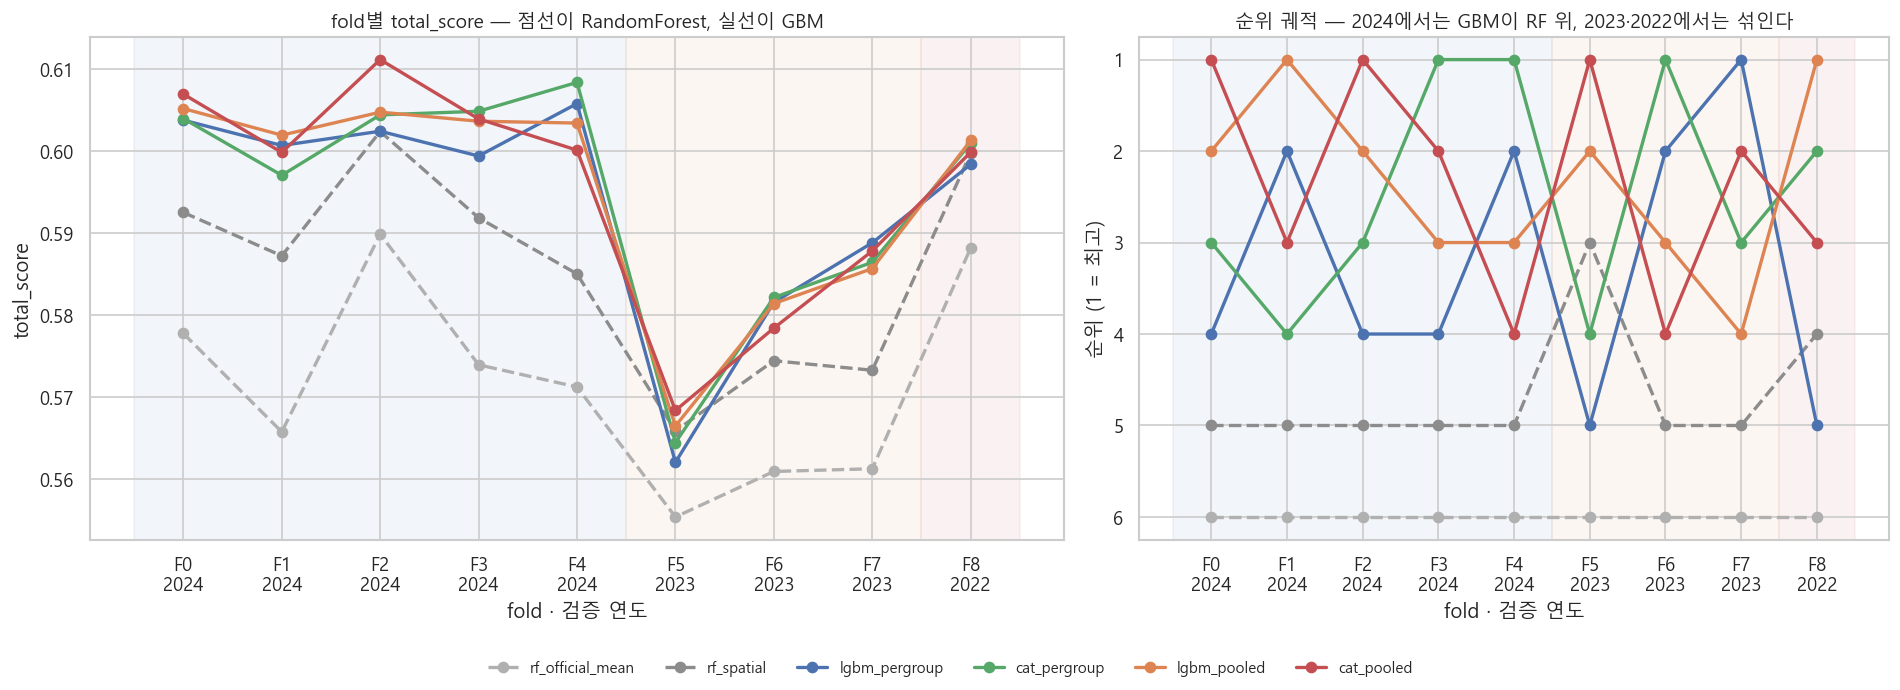

In [8]:
yearColor = {2022: "#c44e52", 2023: "#dd8452", 2024: "#4c72b0"}
candidateColor = dict(zip(CANDIDATES, ["#b0b0b0", "#8c8c8c", "#4c72b0", "#55a868", "#dd8452", "#c44e52"]))
candidateStyle = {name: ("--" if name.startswith("rf") else "-") for name in CANDIDATES}
foldTickLabels = [f"{name}\n{FOLDS[name].valid_year}" for name in foldOrder]
yearSpan = {}
for name in foldOrder:
  yearSpan.setdefault(FOLDS[name].valid_year, []).append(foldOrder.index(name))

fig, axes = plt.subplots(1, 2, figsize=(16, 5.8), gridspec_kw={"width_ratios": [1.3, 1]})
for axis in axes:
  for year, positions in yearSpan.items():
    axis.axvspan(min(positions) - 0.5, max(positions) + 0.5, color=yearColor[year], alpha=0.07, zorder=0)
for candidateName in CANDIDATES:
  axes[0].plot(foldOrder, totalPivot.loc[candidateName], marker="o", label=candidateName,
               color=candidateColor[candidateName], linestyle=candidateStyle[candidateName],
               linewidth=2, zorder=3)
  axes[1].plot(foldOrder, rankPivot.loc[candidateName], marker="o", label=candidateName,
               color=candidateColor[candidateName], linestyle=candidateStyle[candidateName],
               linewidth=2, zorder=3)
axes[0].set_title("fold별 total_score — 점선이 RandomForest, 실선이 GBM", fontsize=11.5)
axes[0].set_ylabel("total_score")
axes[1].set_title("순위 궤적 — 2024에서는 GBM이 RF 위, 2023·2022에서는 섞인다", fontsize=11.5)
axes[1].set_ylabel("순위 (1 = 최고)")
axes[1].set_yticks(range(1, len(CANDIDATES) + 1))
axes[1].invert_yaxis()
for axis in axes:
  axis.set_xlabel("fold · 검증 연도")
  axis.set_xticks(range(len(foldOrder)))
  axis.set_xticklabels(foldTickLabels)
handles, labelTexts = axes[0].get_legend_handles_labels()
fig.legend(handles, labelTexts, loc="lower center", ncol=6, fontsize=9, frameon=False)
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

### 4-1. 2024만 보면 명확하고, 연도를 넓히면 갈라진다

챔피언 `rf_spatial`은 **아홉 fold 어디에서도 1위가 아니다.** GBM 도입은 그 자체로 성공이다.

그런데 오른쪽 패널의 진한 회색 점선을 따라가면 미묘한 지점이 보인다. 2024 구간(F0~F4)에서
`rf_spatial`은 계속 5위인데 **F5에서 3위, F8에서 4위로 올라간다.** GBM 일부가 그 아래로
내려갔다는 뜻이다.

왼쪽 패널에서도 F5·F8은 모양이 다르다. 여섯 후보가 거의 한 점에 모인다.
2023 후반과 2022는 **모델을 무엇으로 쓰든 점수가 비슷해지는 구간**이다.

크기와 부호를 함께 재야 이 차이가 잡힌다.

---

## 5. 판정 — 크기와 방향

In [9]:
deltaVsChampion = totalPivot - totalPivot.loc[CHAMPION]
deltaVsControl = totalPivot - totalPivot.loc[CONTROL]

print("현재 챔피언(rf_spatial) 대비 Δ")
display(deltaVsChampion.drop(index=[CHAMPION]))

folds2024 = [name for name in foldOrder if FOLDS[name].valid_year == 2024]


def judge(delta, folds):
  # 크기와 부호를 함께 본다. 둘 중 하나만으로는 확정하지 않는다.
  values = delta[folds]
  positive, count = int((values > 0).sum()), len(values)
  meanGap = float(values.mean())
  if positive == count and meanGap > RANK_THRESHOLD:
    return meanGap, positive, count, "우위 확정"
  if positive == 0 and abs(meanGap) > RANK_THRESHOLD:
    return meanGap, positive, count, "열위 확정"
  if positive == count:
    return meanGap, positive, count, "잠정 우위 (부호 일치·크기 미달)"
  return meanGap, positive, count, "미확정 (부호 흔들림)"


judgeRows = []
for candidateName in CANDIDATES:
  if candidateName == CHAMPION:
    continue
  delta = deltaVsChampion.loc[candidateName]
  meanGap, positive, count, verdict = judge(delta, foldOrder)
  _, positive2024, count2024, verdict2024 = judge(delta, folds2024)
  judgeRows.append({
    "후보": candidateName, "Δ 평균": meanGap, "Δ 최소": delta.min(), "Δ 최대": delta.max(),
    "문턱 대비": meanGap / RANK_THRESHOLD, "부호 + (9 fold)": f"{positive}/{count}",
    "판정 (9 fold)": verdict,
    "부호 + (2024만)": f"{positive2024}/{count2024}", "판정 (2024만)": verdict2024,
  })
judgeFrame = pd.DataFrame(judgeRows).set_index("후보")
display(judgeFrame)

print(f"순위 문턱 : {RANK_THRESHOLD}")
print(f"통제군(rf_official_mean) 대비 챔피언 Δ 평균 : {deltaVsControl.loc[CHAMPION].mean():.6f}")
print(f"통제군 대비 최고 GBM Δ 평균                 : {deltaVsControl.drop(index=[CONTROL, CHAMPION]).mean(axis=1).max():.6f}")
print()
print("=== 2024 fold만 봤다면 어떤 결론이 나왔을까 ===")
gbmOnly = [name for name in CANDIDATES if name.startswith(("lgbm", "cat"))]
for name in gbmOnly:
  delta = deltaVsChampion.loc[name]
  negative9 = [fold for fold in foldOrder if delta[fold] <= 0]
  print(f"  {name:16s} 2024만 {judgeFrame.loc[name, '부호 + (2024만)']}"
        f" → {judgeFrame.loc[name, '판정 (2024만)']:28s}"
        f" | 9 fold {judgeFrame.loc[name, '부호 + (9 fold)']}"
        f" → {judgeFrame.loc[name, '판정 (9 fold)']}"
        f"{'  음수 fold ' + ','.join(negative9) if negative9 else ''}")

현재 챔피언(rf_spatial) 대비 Δ


fold,F0,F1,F2,F3,F4,F5,F6,F7,F8
후보,,,,,,,,,
rf_official_mean,-0.014743,-0.021442,-0.012503,-0.017902,-0.013775,-0.010477,-0.013490,-0.011998,-0.011555
lgbm_pergroup,0.011239,0.013445,0.000029,0.007530,0.020744,-0.003825,0.007105,0.015525,-0.001356
cat_pergroup,0.011434,0.009814,0.002023,0.012980,0.023325,-0.001419,0.007702,0.013147,0.001222
lgbm_pooled,0.012654,0.014698,0.002356,0.011764,0.018373,0.000605,0.006961,0.012385,0.001553
cat_pooled,0.014411,0.012595,0.008756,0.012049,0.015072,0.002496,0.003972,0.014527,0.000118


,Δ 평균,Δ 최소,Δ 최대,문턱 대비,부호 + (9 fold),판정 (9 fold),부호 + (2024만),판정 (2024만)
후보,,,,,,,,
rf_official_mean,-0.014210,-0.021442,-0.010477,-3.947091,0/9,열위 확정,0/5,열위 확정
lgbm_pergroup,0.007826,-0.003825,0.020744,2.173959,7/9,미확정 (부호 흔들림),5/5,우위 확정
cat_pergroup,0.008914,-0.001419,0.023325,2.476136,8/9,미확정 (부호 흔들림),5/5,우위 확정
lgbm_pooled,0.009039,0.000605,0.018373,2.510743,9/9,우위 확정,5/5,우위 확정
cat_pooled,0.009333,0.000118,0.015072,2.592449,9/9,우위 확정,5/5,우위 확정


순위 문턱 : 0.0036
통제군(rf_official_mean) 대비 챔피언 Δ 평균 : 0.014210
통제군 대비 최고 GBM Δ 평균                 : 0.023542

=== 2024 fold만 봤다면 어떤 결론이 나왔을까 ===
  lgbm_pergroup    2024만 5/5 → 우위 확정                        | 9 fold 7/9 → 미확정 (부호 흔들림)  음수 fold F5,F8
  cat_pergroup     2024만 5/5 → 우위 확정                        | 9 fold 8/9 → 미확정 (부호 흔들림)  음수 fold F5
  lgbm_pooled      2024만 5/5 → 우위 확정                        | 9 fold 9/9 → 우위 확정
  cat_pooled       2024만 5/5 → 우위 확정                        | 9 fold 9/9 → 우위 확정


숫자만으로는 GBM끼리의 차이가 실제인지 알 수 없다. fold 내부 paired bootstrap으로 잰다.
노트북 12·14와 같은 구조다.

In [10]:
BOOTSTRAP_DRAWS = 4000
bestGbm = deltaVsChampion.drop(index=[CHAMPION, CONTROL]).mean(axis=1).idxmax()
runnerGbm = deltaVsChampion.drop(index=[CHAMPION, CONTROL, bestGbm]).mean(axis=1).idxmax()
print(f"GBM 1위 후보 : {bestGbm}")
print(f"GBM 2위 후보 : {runnerGbm}\n")

bootRows = []
bootStarted = time.perf_counter()
for foldName in foldOrder:
  columns = foldScoreColumns[foldName]
  windowName = FOLDS[foldName].train_window
  terms = {
    name: group_error_terms(trainLabels, predictionCache[(name, windowName)], foldName, columns)
    for name in [bestGbm, runnerGbm, CHAMPION]
  }
  vsChampion = paired_bootstrap_gap(terms[bestGbm], terms[CHAMPION], draws=BOOTSTRAP_DRAWS)
  vsRunner = paired_bootstrap_gap(terms[bestGbm], terms[runnerGbm], draws=BOOTSTRAP_DRAWS)
  bootRows.append({
    "fold": foldName, "검증 연도": FOLDS[foldName].valid_year,
    f"{bestGbm}−챔피언": float(deltaVsChampion.loc[bestGbm, foldName]),
    "P(>챔피언)": float((vsChampion > 0).mean()),
    f"{bestGbm}−{runnerGbm}": float(totalPivot.loc[bestGbm, foldName] - totalPivot.loc[runnerGbm, foldName]),
    "P(GBM 1·2위)": float((vsRunner > 0).mean()),
  })
bootstrapFrame = pd.DataFrame(bootRows).set_index("fold")
display(bootstrapFrame)
print(f"bootstrap {BOOTSTRAP_DRAWS}회 × {len(foldOrder)} fold × 2쌍 · {time.perf_counter() - bootStarted:.1f}s")
print()
print(f"{bestGbm} > 챔피언이 전 fold에서 P>0.99인가 : {bool((bootstrapFrame['P(>챔피언)'] > 0.99).all())}")
print(f"GBM 1·2위 P 범위 : {bootstrapFrame['P(GBM 1·2위)'].min():.3f} ~ {bootstrapFrame['P(GBM 1·2위)'].max():.3f}")

GBM 1위 후보 : cat_pooled
GBM 2위 후보 : lgbm_pooled



,검증 연도,cat_pooled−챔피언,P(>챔피언),cat_pooled−lgbm_pooled,P(GBM 1·2위)
fold,,,,,
F0,2024,0.014411,1.000000,0.001758,0.877000
F1,2024,0.012595,1.000000,-0.002104,0.157750
F2,2024,0.008756,0.997500,0.006400,0.995500
F3,2024,0.012049,1.000000,0.000285,0.561500
F4,2024,0.015072,1.000000,-0.003300,0.070250
F5,2023,0.002496,0.833500,0.001890,0.830250
F6,2023,0.003972,0.984250,-0.002989,0.018250
F7,2023,0.014527,1.000000,0.002142,0.889000
F8,2022,0.000118,0.523000,-0.001435,0.206000


bootstrap 4000회 × 9 fold × 2쌍 · 40.5s

cat_pooled > 챔피언이 전 fold에서 P>0.99인가 : False
GBM 1·2위 P 범위 : 0.018 ~ 0.996


### 5-1. pooled만 아홉 fold를 견딘다

판정이 후보를 둘로 가른다.

| 후보 | Δ 평균 (문턱 대비) | 부호 (9 fold) | 판정 |
|------|---:|---:|------|
| `cat_pooled` | 2.59배 | **9/9** | 우위 확정 |
| `lgbm_pooled` | 2.51배 | **9/9** | 우위 확정 |
| `cat_pergroup` | 2.48배 | 8/9 | 미확정 (F5에서 음수) |
| `lgbm_pergroup` | 2.17배 | 7/9 | 미확정 (F5·F8에서 음수) |

네 후보 모두 **평균 개선분은 문턱의 2배를 넘는다.** 갈리는 것은 부호다.
그룹별 GBM은 F5(2023 후반)와 F8(2022)에서 챔피언 아래로 내려간다.

**이것이 이 노트북에서 가장 중요한 줄이다 — 2024 fold만 봤다면 네 후보 모두 5/5로
통과했을 것이다.** 노트북 14가 만든 cross-year fold가 도입 직후 첫 후보 심사에서 바로
값을 했다. 위 출력의 마지막 블록이 그 대조를 직접 보여준다.

표의 `rf_official_mean` 행이 "열위 확정"인 것도 읽어 둔다 — 통제군이 확정적으로
**나쁘다**는 뜻이다. 부호가 0/9이고 크기가 문턱을 넘는다.

**판정 규칙을 손봐야 한다.** 설계서 06 5.4절 첫째 칸은 "간격 > 0.0036이면 순위 확정"인데,
그대로 읽으면 `lgbm_pergroup`(평균 0.0078)도 확정이 된다. 부호가 두 fold에서 뒤집히는데도
그렇다. 이 노트북은 첫째 칸에 부호 조건을 함께 걸었고 그 결정을 Decision Box ㉕로 남긴다.

그림으로 확인한다.

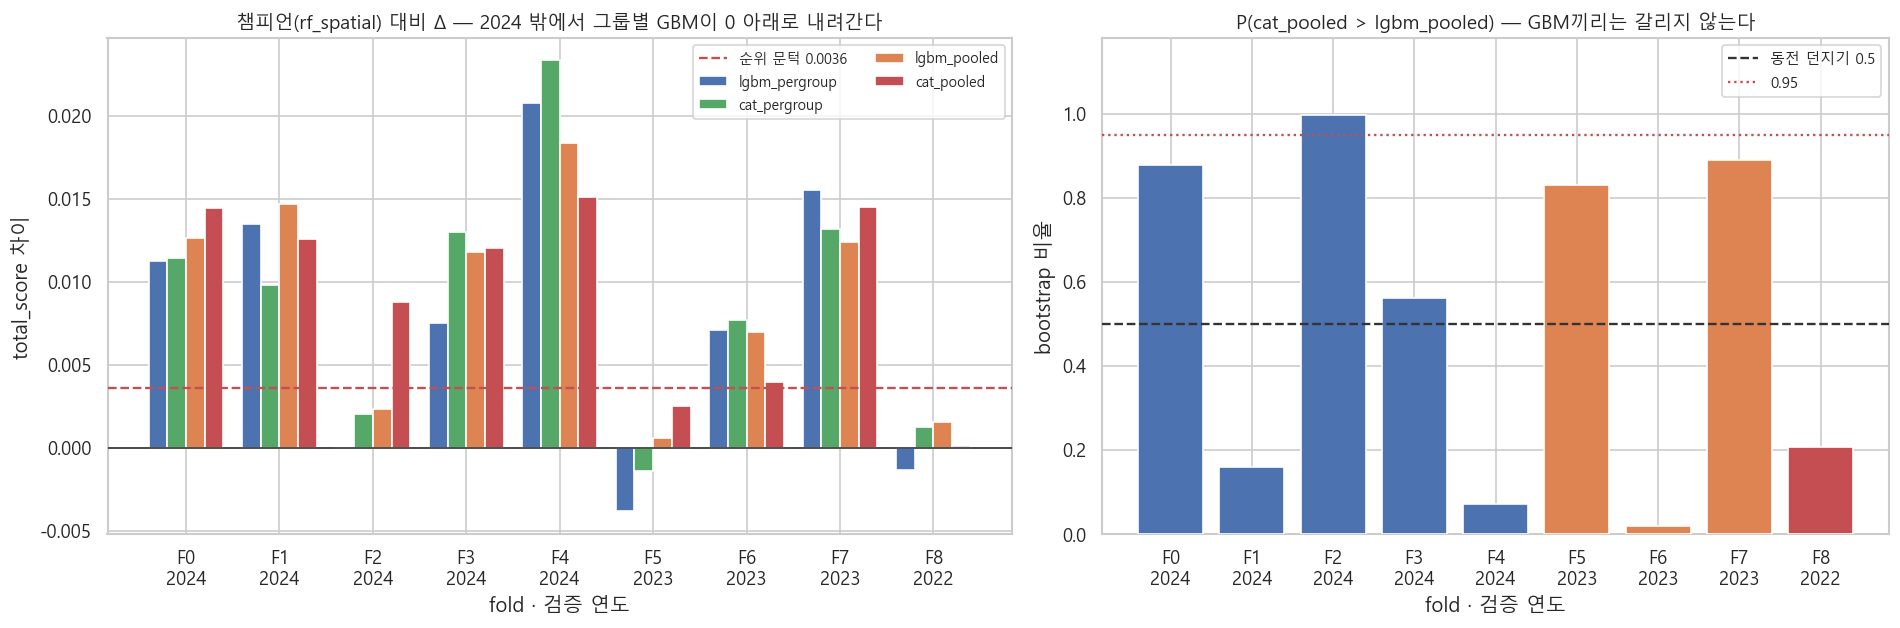

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.4), gridspec_kw={"width_ratios": [1.15, 1]})

gbmNames = [name for name in CANDIDATES if name.startswith(("lgbm", "cat"))]
width = 0.2
positions = np.arange(len(foldOrder))
for offset, name in zip(np.linspace(-1.5, 1.5, len(gbmNames)) * width, gbmNames):
  axes[0].bar(positions + offset, [deltaVsChampion.loc[name, fold] for fold in foldOrder],
              width, label=name, color=candidateColor[name], zorder=3)
axes[0].axhline(0, color="#333333", linewidth=1, zorder=4)
axes[0].axhline(RANK_THRESHOLD, color="#c44e52", linestyle="--", linewidth=1.4, zorder=4,
                label=f"순위 문턱 {RANK_THRESHOLD}")
axes[0].set_xticks(positions)
axes[0].set_xticklabels(foldTickLabels)
axes[0].set_title("챔피언(rf_spatial) 대비 Δ — 2024 밖에서 그룹별 GBM이 0 아래로 내려간다", fontsize=11.5)
axes[0].set_ylabel("total_score 차이")
axes[0].set_xlabel("fold · 검증 연도")
axes[0].legend(fontsize=8.5, ncol=2)

barColors = [yearColor[FOLDS[name].valid_year] for name in foldOrder]
axes[1].bar(foldOrder, [bootstrapFrame.loc[name, "P(GBM 1·2위)"] for name in foldOrder],
            color=barColors, zorder=3)
axes[1].axhline(0.5, color="#333333", linestyle="--", linewidth=1.4, zorder=4, label="동전 던지기 0.5")
axes[1].axhline(0.95, color="#c44e52", linestyle=":", linewidth=1.4, zorder=4, label="0.95")
axes[1].set_ylim(0, 1.18)
axes[1].set_xticks(positions)
axes[1].set_xticklabels(foldTickLabels)
axes[1].set_title(f"P({bestGbm} > {runnerGbm}) — GBM끼리는 갈리지 않는다", fontsize=11.5)
axes[1].set_ylabel("bootstrap 비율")
axes[1].set_xlabel("fold · 검증 연도")
axes[1].legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.show()

왼쪽 패널에서 F5와 F8의 막대만 0 아래로 내려간다. 파랑(`lgbm_pergroup`)과
초록(`cat_pergroup`)이 그 주인공이고 주황·빨강(pooled 둘)은 0 위에 남는다.

오른쪽은 노트북 14에서 본 그림과 같은 모양이다 — GBM 1·2위 확률이 0.018에서 0.996까지
fold마다 요동친다. **어느 GBM이 가장 나은지는 답할 수 없다.**

---

## 6. 비용을 함께 읽는다

CatBoost와 LightGBM의 점수 차이를 학습 시간과 나란히 놓는다.

In [12]:
compareRows = []
for name in gbmNames:
  delta = deltaVsChampion.loc[name]
  compareRows.append({
    "후보": name,
    "Δ 평균 (챔피언 대비)": float(delta.mean()),
    "Δ SD": float(delta.std(ddof=1)),
    "총 학습 초": float(costFrame.loc[name, "총 초"]),
    "챔피언 대비 시간": float(costFrame.loc[name, "챔피언 대비"]),
  })
compareFrame = pd.DataFrame(compareRows).set_index("후보")
compareFrame["Δ / 시간배수"] = compareFrame["Δ 평균 (챔피언 대비)"] / compareFrame["챔피언 대비 시간"]
display(compareFrame)

lgbmBest = compareFrame.loc[[n for n in gbmNames if n.startswith("lgbm")], "Δ 평균 (챔피언 대비)"].max()
catBest = compareFrame.loc[[n for n in gbmNames if n.startswith("cat")], "Δ 평균 (챔피언 대비)"].max()
lgbmTime = compareFrame.loc[[n for n in gbmNames if n.startswith("lgbm")], "총 학습 초"].sum()
catTime = compareFrame.loc[[n for n in gbmNames if n.startswith("cat")], "총 학습 초"].sum()
print(f"\nLightGBM 최고 Δ {lgbmBest:.6f} · CatBoost 최고 Δ {catBest:.6f}")
print(f"차이 {catBest - lgbmBest:+.6f} — 문턱 {RANK_THRESHOLD}의 {abs(catBest - lgbmBest) / RANK_THRESHOLD:.2f}배")
print(f"학습 시간 : LightGBM {lgbmTime:.0f}s vs CatBoost {catTime:.0f}s ({catTime / lgbmTime:.1f}배)")

pooledNames = [n for n in gbmNames if n.endswith("pooled")]
perGroupNames = [n for n in gbmNames if n.endswith("pergroup")]
pooledDelta = deltaVsChampion.loc[pooledNames].mean(axis=1).mean()
perGroupDelta = deltaVsChampion.loc[perGroupNames].mean(axis=1).mean()
print(f"\npooled 평균 Δ {pooledDelta:.6f} vs 그룹별 평균 Δ {perGroupDelta:.6f}"
      f"  차이 {pooledDelta - perGroupDelta:+.6f} (문턱의 {abs(pooledDelta - perGroupDelta) / RANK_THRESHOLD:.2f}배)")

,Δ 평균 (챔피언 대비),Δ SD,총 학습 초,챔피언 대비 시간,Δ / 시간배수
후보,,,,,
lgbm_pergroup,0.007826,0.008298,147.991622,2.226019,0.003516
cat_pergroup,0.008914,0.007617,1082.434522,16.281463,0.000547
lgbm_pooled,0.009039,0.006393,185.094996,2.784111,0.003247
cat_pooled,0.009333,0.005750,437.079829,6.574346,0.001420



LightGBM 최고 Δ 0.009039 · CatBoost 최고 Δ 0.009333
차이 +0.000294 — 문턱 0.0036의 0.08배
학습 시간 : LightGBM 333s vs CatBoost 1520s (4.6배)

pooled 평균 Δ 0.009186 vs 그룹별 평균 Δ 0.008370  차이 +0.000816 (문턱의 0.23배)


### 6-1. pooled의 진짜 이점은 점수가 아니다

pooled와 그룹별의 점수 차이는 문턱 아래다. 그런데 pooled에는 점수로 잡히지 않는
능력이 하나 있다 — **학습 라벨이 없는 그룹을 예측한다.**

F7은 train이 2022뿐이라 Group 3 라벨이 0행이고, 그룹별 모델은 Group 3을 아예 학습할 수 없어
채점에서 빠진다. pooled는 group id만 바꿔 Group 3을 내놓는다. 그 예측이 쓸 만한지 확인한다.

In [13]:
transferRows = []
for name in CANDIDATES:
  predictions = predictionCache[(name, FOLDS["F7"].train_window)]
  twoGroup, _, _ = score_fold(trainLabels, predictions, "F7", columns=TARGET_COLS[:2])
  hasGroup3 = bool(predictions["kpx_group_3"].notna().all())
  threeGroup = (
    float(score_fold(trainLabels, predictions, "F7", columns=TARGET_COLS)[0]) if hasGroup3 else np.nan
  )
  transferRows.append({"후보": name, "F7 (2그룹, 표준)": twoGroup,
                       "Group 3 예측 가능": hasGroup3, "F7 (3그룹)": threeGroup})
transferFrame = pd.DataFrame(transferRows).set_index("후보")
display(transferFrame)

# 비교 기준 — 같은 fold를 Group 3 라벨이 있는 창으로 학습했을 때의 3그룹 점수
reference = float(score_fold(trainLabels, predictionCache[(bestGbm, FOLDS["F6"].train_window)], "F6")[0])
pooledF7 = transferFrame.loc[pooledNames, "F7 (3그룹)"]
print(f"\npooled만 Group 3을 낸다 : {list(transferFrame.loc[transferFrame['Group 3 예측 가능'], :].index)}")
print(f"pooled F7 3그룹 점수 : {dict(pooledF7.round(6))}")
print(f"참고 — 같은 후보의 F6(2024 학습, Group 3 라벨 있음) 3그룹 점수 : {reference:.6f}")
print("\nF7의 Group 3 예측은 라벨을 한 번도 보지 않고 나온 것이다.")

,"F7 (2그룹, 표준)",Group 3 예측 가능,F7 (3그룹)
후보,,,
rf_official_mean,0.561265,False,NaN
rf_spatial,0.573263,False,NaN
lgbm_pergroup,0.588788,False,NaN
cat_pergroup,0.586410,False,NaN
lgbm_pooled,0.585648,True,0.582940
cat_pooled,0.587790,True,0.584345



pooled만 Group 3을 낸다 : ['lgbm_pooled', 'cat_pooled']
pooled F7 3그룹 점수 : {'lgbm_pooled': 0.58294, 'cat_pooled': 0.584345}
참고 — 같은 후보의 F6(2024 학습, Group 3 라벨 있음) 3그룹 점수 : 0.578397

F7의 Group 3 예측은 라벨을 한 번도 보지 않고 나온 것이다.


### 6-2. 이 능력을 어디까지 주장할 수 있나

**주장할 수 있는 것:** pooled 모델은 학습 창에 Group 3 라벨이 없어도 Group 3 예측을
만들어내며, 그 예측으로 3그룹 채점이 성립한다.

**주장할 수 없는 것:** 이 전이가 "좋다"는 것. F7의 3그룹 점수(0.582940)는 Group 3
라벨을 쓴 F6(0.578397)보다 **오히려 높다.** 그러나 두 fold는 학습 창도 검증 구간도
달라 수준을 비교할 수 없다 — 높게 나왔다는 사실을 전이가 잘 됐다는 근거로 쓸 수 없다.

**실전에서 중요한가?** 2025 제출 구간은 세 그룹 모두 예측해야 하고 학습에는 2023~2024
Group 3 라벨이 **있다.** 즉 이 능력이 제출에 직접 필요하지는 않다.
쓸모가 있다면 **학습 창을 2022까지 넓힐 때**다 — 그룹별 모델은 Group 3에 2022를 못 쓰지만
pooled는 2022의 Group 1·2 라벨로 Group 3 예측을 함께 개선할 여지가 있다.
그것이 사실인지는 이 노트북의 범위 밖이다.

---

## 7. 종합 결론

### 7-1. 연구 질문

In [14]:
championDelta = deltaVsChampion.drop(index=[CHAMPION, CONTROL])
yearsCovered = sorted({spec.valid_year for spec in FOLDS.values()})

robust = [name for name in gbmNames if judgeFrame.loc[name, "판정 (9 fold)"] == "우위 확정"]
fragile = [name for name in gbmNames if judgeFrame.loc[name, "판정 (9 fold)"] != "우위 확정"]
allAbove2024 = all(judgeFrame.loc[name, "판정 (2024만)"] == "우위 확정" for name in gbmNames)

conclusion = pd.DataFrame({
  "항목": ["GBM이 챔피언을 앞선 fold", "9 fold에서 우위 확정", "9 fold에서 미확정",
           "2024 fold만 봤다면 전부 우위 확정인가", "검증 연도",
           "CatBoost−LightGBM 차이", "pooled−그룹별 차이", "GBM 1·2위 bootstrap P 범위"],
  "값": [f"{int((championDelta > 0).sum().sum())}/{championDelta.size}",
         ", ".join(robust) or "없음",
         ", ".join(fragile) or "없음",
         str(allAbove2024),
         f"{len(yearsCovered)}개 {yearsCovered}",
         f"{catBest - lgbmBest:+.6f} (문턱의 {abs(catBest - lgbmBest) / RANK_THRESHOLD:.2f}배)",
         f"{pooledDelta - perGroupDelta:+.6f} (문턱의 {abs(pooledDelta - perGroupDelta) / RANK_THRESHOLD:.2f}배)",
         f"{bootstrapFrame['P(GBM 1·2위)'].min():.3f} ~ {bootstrapFrame['P(GBM 1·2위)'].max():.3f}"],
}).set_index("항목")
display(conclusion)

print(f"우위가 아홉 fold를 견딘 후보 : {robust}")
print(f"2024만 봤다면 전부 통과했을 것인가 : {allAbove2024}")
print(f"F0 재현 게이트 통과 : {reproductionOk}")

,값
항목,
GBM이 챔피언을 앞선 fold,33/36
9 fold에서 우위 확정,"lgbm_pooled, cat_pooled"
9 fold에서 미확정,"lgbm_pergroup, cat_pergroup"
2024 fold만 봤다면 전부 우위 확정인가,True
검증 연도,"3개 [2022, 2023, 2024]"
CatBoost−LightGBM 차이,+0.000294 (문턱의 0.08배)
pooled−그룹별 차이,+0.000816 (문턱의 0.23배)
GBM 1·2위 bootstrap P 범위,0.018 ~ 0.996


우위가 아홉 fold를 견딘 후보 : ['lgbm_pooled', 'cat_pooled']
2024만 봤다면 전부 통과했을 것인가 : True
F0 재현 게이트 통과 : True


> **GBM은 현재 챔피언보다 나은가?**

**pooled는 확정적으로 낫다. 그룹별은 확정할 수 없다.**

챔피언 `rf_spatial`은 아홉 fold 어디에서도 1위가 아니고, GBM 네 후보 모두 평균
개선분이 문턱의 2.2~2.6배다. 그러나 부호까지 보면 `cat_pooled`·`lgbm_pooled`만 9/9이고
`cat_pergroup`은 8/9, `lgbm_pergroup`은 7/9다.

> **그 우위는 아홉 fold·세 검증 연도를 건너 유지되는가?**

**pooled만 유지된다.** 그리고 이 구분은 **2024 fold만 봤다면 보이지 않았다** —
F0~F4에서는 네 후보 모두 5/5 양수다.

> **어느 GBM이 가장 나은가?**

**답할 수 없다.** CatBoost−LightGBM 차이는 문턱의 0.08배, pooled−그룹별 차이는 0.23배이고,
fold 내부 bootstrap에서 1·2위 확률이 0.018~0.996으로 요동친다.

### 7-2. 단계별 요약

| 절 | 확인한 것 | 결과 |
|----|-----------|------|
| 1 | 후보 고정 | 6개 사전 등록, 하이퍼파라미터 탐색 없음 (Decision Box ㉔) |
| 3 | 재현 게이트 | RF 두 후보가 노트북 14와 절대 차이 0.0 |
| 4 | 순위 | 챔피언이 1위인 fold 0/9. 다만 F5·F8에서 챔피언이 순위를 회복 |
| 5 | 크기·방향 | 평균은 넷 다 문턱 초과, **부호는 pooled 둘만 9/9** |
| 6 | 비용·pooled | CatBoost는 4.56배 비싼데 차이는 문턱의 0.08배. pooled는 라벨 없는 그룹을 예측 |

### 7-3. 주요 발견

1. **cross-year fold가 도입 직후 값을 했다.** 2024 fold 다섯 개만 봤다면 GBM 네 후보가
   전부 "5/5 부호 일치"로 통과했을 것이다. 검증 연도를 셋으로 넓히자 그룹별 GBM 둘이
   걸러졌다. 노트북 14가 경고한 실패 모드가 **바로 다음 작업에서 실제로 발생했다.**
2. **모델 교체가 피처 추가만큼 이겼다.** 노트북 08~11이 피처로 얻은 개선분은 통제군 대비
   0.0142였고, GBM은 그 위에 다시 0.0093을 더한다(통제군 대비로는 0.0235).
   같은 피처·같은 fold·같은 전처리에서 모델만 바꾼 결과다.
3. **지표 분해는 이 노트북이 확인하지 않았다.** 셀 13이 `one_minus_nmae`와 `ficr`를
   `scoreFrame`에 담지만 표시하지 않으므로, "개선분이 FICR에서 나온다"는 노트북
   11·12·13의 관찰이며 **모델을 바꾼 뒤에도 그런지는 여기서 확인되지 않았다.**
4. **비용 차이가 점수 차이보다 훨씬 크다.** CatBoost는 LightGBM보다 4.56배 느린데
   점수 차이는 문턱의 0.08배다. 반복 실행이 필요한 후속 작업에서는 LightGBM이 합리적이다.
5. **F5·F8은 모델을 가리지 않는 구간이다.** 두 fold에서 여섯 후보의 점수가 거의 모인다.
   왜 그런지는 이 노트북이 답하지 않는다 — 남겨 둔 질문이다.

### 7-4. 한계

- **하이퍼파라미터를 탐색하지 않았다.** 각 라이브러리의 최선이 아니라 고정값 하나의
  결과다. "GBM이 이긴다"는 결론에는 보수적이지만 "얼마나"에는 아니다.
- **피처셋을 고정했다.** GBM에 맞는 피처셋이 따로 있을 가능성이 남는다.
- **아직 제출하지 않았다.** 전부 local이며 Public은 40% 표본이다(설계서 06 5.3절).
- **fold 아홉 개는 서로 독립이 아니다**(노트북 14 7-4절과 동일).
- **후보 6개를 같은 fold로 쟀다.** 최고점의 낙관 편향이 있으며 "최고가 누구인가"를
  확정하지 않는 것으로 대응했다.
- **pooled를 고른 근거는 부호이지 크기가 아니다.** pooled−그룹별 점수 차이 자체는
  문턱의 0.23배로 확정할 수 없다. 확정된 것은 "pooled의 챔피언 대비 우위가 아홉 fold를
  견딘다"이지 "pooled가 그룹별보다 낫다"가 아니다.

### 7-5. 요약

사전 등록한 후보 6종을 아홉 fold에서 채점했다. 챔피언 `rf_spatial`은 **아홉 fold
어디에서도 1위가 아니었고**, GBM 네 후보의 평균 개선분은 문턱의 2.2~2.6배였다.
그러나 부호까지 보면 **pooled 둘만 9/9**이고 그룹별 둘은 F5·F8에서 음수로 내려간다.
2024 fold만 봤다면 넷 다 통과했을 것이다.

### Decision Box ㉕ — 판정표 첫째 칸에도 부호 조건을 건다

**선택지**

- (A) 설계서 06 5.4절 첫째 칸을 그대로 둔다 — 간격 > 0.0036이면 확정
- (B) 첫째 칸에 **검증 연도를 덮는 fold 전부에서 부호 일치**를 함께 요구한다

**근거**

(A)를 그대로 적용하면 `lgbm_pergroup`(평균 0.0078 = 문턱의 2.17배)이 "확정"이 된다.
그런데 이 후보는 F5에서 −0.003825, F8에서 −0.001356으로 챔피언 아래다.
**평균이 큰 것과 어디서나 나은 것은 다른 주장이다.**

노트북 14가 둘째 칸(크기 미달)에는 연도 조건을 걸었지만 첫째 칸에는 걸지 않았다.
당시에는 크기가 문턱을 넘으면서 부호가 흔들리는 후보가 없어 드러나지 않았을 뿐이다.
이번에 그 조합이 실제로 나왔다.

**채택: (B)** — 판정표를 다음으로 바꾼다.

| 상황 | 판정 |
|------|------|
| 간격 > 0.0036 **이고** 검증 연도를 덮는 fold 전부에서 부호 일치 | 순위 확정 |
| 간격 ≤ 0.0036 이지만 검증 연도를 덮는 fold 전부에서 부호 일치 | 잠정 채택 |
| 부호가 흔들림 (크기와 무관) | 순위 미확정 — 더 단순한 후보 유지 |

셋째 칸이 "크기와 무관"으로 바뀐 것이 핵심이다. **부호가 흔들리면 크기는 보지 않는다.**

### Decision Box ㉖ — pooled GBM으로 전환하고 작업 모델은 LightGBM으로 둔다

**선택지**

- (A) RandomForest 챔피언을 유지한다
- (B) GBM으로 갈아타고 네 후보를 모두 유지한다
- (C) **pooled GBM으로 갈아타고 그룹별은 후보에서 내린다**

**근거**

(A)는 근거가 없다. 챔피언은 아홉 fold 어디에서도 1위가 아니다.

(B)는 방금 세운 규칙을 스스로 어긴다. 그룹별 GBM 둘은 부호가 흔들려 셋째 칸이다.

(C)에서 주의할 것은 **근거의 종류**다. pooled를 고르는 이유는 "pooled가 그룹별보다
점수가 높아서"가 아니다 — 그 차이는 문턱의 0.23배로 확정할 수 없다. 이유는
**pooled의 챔피언 대비 우위만 아홉 fold를 견뎠다**는 것이다.

**채택: (C)**

| 항목 | 결정 |
|------|------|
| 모델 계열 | **GBM pooled로 전환.** RandomForest는 통제군·재현 기준선으로만 남긴다 |
| 작업 모델 | **`lgbm_pooled`** — CatBoost와 점수가 구분되지 않는데 4.56배 싸다 |
| 그룹별 GBM | 후보에서 내린다. 다시 올리려면 부호가 아홉 fold에서 일치해야 한다 |
| `cat_pooled` | 최종 제출 후보로는 남긴다. 작업용으로는 쓰지 않는다 |
| 하이퍼파라미터 | 고정값 유지 (Decision Box ㉔) |
| 제출 | 이번 작업에서는 하지 않는다. calibration(M6) 이후 함께 판정한다 |

---

## 산출물 확인

In [15]:
print("이 노트북이 쓴 파일 : 없음 (분석 전용)")
print(f"학습한 모델        : {len(predictionCache)}회 (메모리에만 존재, 저장하지 않음)")
print(f"총 학습 시간       : {timingFrame['초'].sum():.0f}s")
print()
print(f"F0 재현 게이트 통과              : {reproductionOk}")
print(f"우위 확정 후보                   : {robust}")
print(f"미확정 후보                      : {fragile}")
print(f"작업 모델로 채택                 : lgbm_pooled")

이 노트북이 쓴 파일 : 없음 (분석 전용)
학습한 모델        : 36회 (메모리에만 존재, 저장하지 않음)
총 학습 시간       : 1932s

F0 재현 게이트 통과              : True
우위 확정 후보                   : ['lgbm_pooled', 'cat_pooled']
미확정 후보                      : ['lgbm_pergroup', 'cat_pergroup']
작업 모델로 채택                 : lgbm_pooled


이 노트북은 파일을 만들지 않는다. 모델도 제출물도 저장하지 않으며 원자료와 라벨은
읽기만 했다.

다음 단계는 설계서 04 7.1절의 **M6 — metric-aware calibration**이다. 그 근거는 이
노트북이 아니라 노트북 11·12·13이다 (위 발견 3). 개선분이 세 번째 노트북 연속으로 FICR에서 나왔고, FICR은 6%·8%
계단 함수다. 오차율 분포를 계단 경계에 대해 다듬는 것이 남은 가장 큰 지렛대로 보인다.
판정은 같은 아홉 fold와 Decision Box ㉓·㉕의 규칙으로 한다.